# TARDIS — Analytics des retards ferroviaires (EDA & cleaning)

## Fil conducteur

1. **Problème** — Jeu tabulaire OD × mois pour analyser punctuality, retards, annulations.
2. **Qualité** — Formats mixtes, NA, labels bruités, doublons, colonnes commentaires (hors scope NLP).
3. **Cleaning** — Preuve visuelle (avant/après), puis normalisation stations / `Service`, types, doublons.
4. **Features** — Calendrier, `route`, ratios métier (`cancel_rate`, `severe_delay_rate`, …).
5. **EDA** — Distributions, corrélations, série temporelle, gares / routes.
6. **Livrable** — `cleaned_dataset.csv`.

## 1. Imports & configuration

In [92]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda x: f"{x:.4g}")

FIG = {"sm": (10, 5), "md": (10, 6), "lg": (12, 5), "xl": (14, 7), "sq": (8, 6), "heat": (14, 10)}
PAL = {"delay": "#4a90a4", "route": "crest", "box": "pastel"}
PAL_CANCEL_BAR = "rocket"
CMAP = {"missing": "YlOrRd", "corr": "coolwarm"}

sns.set_theme(style="whitegrid")
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["figure.titlesize"] = 14

## 2. Chargement

### 2.0 Lecture CSV + `strip` des noms de colonnes

Juste après ces deux lignes, on crée **`raw_df = df.copy()`** : c’est la **référence « avant nettoyage »** (plus tard le notebook modifie **`df`** seulement ; **`raw_df`** ne doit pas être réécrit).

In [93]:
CSV_PATH = "dataset.csv"

df = pd.read_csv(CSV_PATH, sep=";", na_values=["N/A", "", " "], engine="python")
df.columns = df.columns.str.strip()

# Snapshot avant tout nettoyage : obligatoire pour les sections 6 et 7 (avant / après)
raw_df = df.copy()

print("Shape df (après strip colonnes) :", df.shape)
print("Exemple de colonnes :", list(df.columns[:6]), "...")
print("raw_df cree : copie independante de df ?", raw_df is not df)

Shape df (après strip colonnes) : (10840, 26)
Exemple de colonnes : ['Date', 'Service', 'Departure station', 'Arrival station', 'Average journey time', 'Number of scheduled trains'] ...
raw_df cree : copie independante de df ? True


### 2.1 La variable `raw_df` (preuve dans les sorties)

La cellule suivante affiche explicitement **`raw_df`** (aperçu). Si tu ne vois pas **`raw_df`** dans ton IDE, recharge le fichier depuis le disque (**Revert File**) : tu regardes peut‑être une ancienne version du notebook.

In [94]:
# Reference avant nettoyage — meme contenu que df a ce stade, objet pandas distinct
assert raw_df is not df
print("raw_df.shape :", raw_df.shape)
print("Colonnes (extrait) :", list(raw_df.columns[:8]))
display(raw_df.head(3))

raw_df.shape : (10840, 26)
Colonnes (extrait) : ['Date', 'Service', 'Departure station', 'Arrival station', 'Average journey time', 'Number of scheduled trains', 'Number of cancelled trains', 'Cancellation comments']


,Date,Service,Departure station,Arrival station,Average journey time,Number of scheduled trains,Number of cancelled trains,Cancellation comments,Number of trains delayed at departure,Average delay of late trains at departure,Average delay of all trains at departure,Departure delay comments,Number of trains delayed at arrival,Average delay of late trains at arrival,Average delay of all trains at arrival,Arrival delay comments,Number of trains delayed > 15min,Average delay of trains > 15min (if competing with flights),Number of trains delayed > 30min,Number of trains delayed > 60min,Pct delay due to external causes,Pct delay due to infrastructure,Pct delay due to traffic management,Pct delay due to rolling stock,Pct delay due to station management and equipment reuse,"Pct delay due to passenger handling (crowding, disabled persons, connections)"
0,2018-01,National,BORDEAUX ST JEAN,PARIS MONTPARNASSE,141,NaN,5,NaN,289,11.25,3.693,NaN,147,28.44,6.511,NaN,110,346.5,44,8,36.13,31.09,10.92,15.97,5.042,75.92
1,2018-01,National,LA ROCHELLE VILLE,PARIS MONTPARNASSE,165,222,NaN,NaN,8,2.875,0.0958,NaN,34,21.52,5.696,NaN,22,5.696,5,NaN,15.38,30.77,38.46,11.54,3.846,0
2,2018-01,National,PARIS MONTPARNASSE,QUIMPER,220,248,1,NaN,37,9.501,NaN,NaN,NaN,55.69,7.579,"Ce mois-ci, l'OD a été touchée par les inciden...",26,7.548,17,7,26.92,38.46,NaN,19.23,0,0


## 3. Inspection initiale

In [95]:
display(df.head())

print("\n--- info() ---")
df.info()

print("\n--- describe() — numériques ---")
display(df.describe())

print("\n--- describe(include=['object']) ---")
display(df.describe(include=["object"]))

# Diagnostic des valeurs négatives sur la cible
TARGET = "Average delay of all trains at arrival"
negatifs = df[df[TARGET] < 0][TARGET]

print(f"Nombre de valeurs négatives : {len(negatifs)}")
print(f"Médiane : {negatifs.median():.2f} min")
print(f"Moyenne : {negatifs.mean():.2f} min")
print(f"Min     : {negatifs.min():.2f} min")
print(f"Max     : {negatifs.max():.2f} min")

# Check répartition des NaN
nan_target = df[df[TARGET].isna()]
print(nan_target["Service"].value_counts())
print(nan_target["Date"].value_counts().head(10))

,Date,Service,Departure station,Arrival station,Average journey time,Number of scheduled trains,Number of cancelled trains,Cancellation comments,Number of trains delayed at departure,Average delay of late trains at departure,Average delay of all trains at departure,Departure delay comments,Number of trains delayed at arrival,Average delay of late trains at arrival,Average delay of all trains at arrival,Arrival delay comments,Number of trains delayed > 15min,Average delay of trains > 15min (if competing with flights),Number of trains delayed > 30min,Number of trains delayed > 60min,Pct delay due to external causes,Pct delay due to infrastructure,Pct delay due to traffic management,Pct delay due to rolling stock,Pct delay due to station management and equipment reuse,"Pct delay due to passenger handling (crowding, disabled persons, connections)"
0,2018-01,National,BORDEAUX ST JEAN,PARIS MONTPARNASSE,141,NaN,5,NaN,289,11.25,3.693,NaN,147,28.44,6.511,NaN,110,346.5,44,8,36.13,31.09,10.92,15.97,5.042,75.92
1,2018-01,National,LA ROCHELLE VILLE,PARIS MONTPARNASSE,165,222,NaN,NaN,8,2.875,0.0958,NaN,34,21.52,5.696,NaN,22,5.696,5,NaN,15.38,30.77,38.46,11.54,3.846,0
2,2018-01,National,PARIS MONTPARNASSE,QUIMPER,220,248,1,NaN,37,9.501,NaN,NaN,NaN,55.69,7.579,"Ce mois-ci, l'OD a été touchée par les inciden...",26,7.548,17,7,26.92,38.46,NaN,19.23,0,0
3,2018j01,National,PARIS MONTPARNASSE,ST MALO,156,102,0,NaN,12,19.91,1.967,NaN,13,48.62,6.791,"Ce mois-ci, l'OD a été touchée par les inciden...",8,6.725,6,4,23.08,218.7,7.692,15.38,7.692,NaN
4,2018-01,National,PARIS MONTPARNASSE,ST PIERRE DES CORPS,61,391,2,NaN,61,NaN,0.8869,NaN,71,12.41,3.346,NaN,17,3.346,6,0,21.21,42.42,9.091,21.21,6.061,0



--- info() ---
<class 'pandas.DataFrame'>
RangeIndex: 10840 entries, 0 to 10839
Data columns (total 26 columns):
 #   Column                                                                         Non-Null Count  Dtype  
---  ------                                                                         --------------  -----  
 0   Date                                                                           10299 non-null  str    
 1   Service                                                                        10288 non-null  str    
 2   Departure station                                                              10298 non-null  str    
 3   Arrival station                                                                10293 non-null  str    
 4   Average journey time                                                           10010 non-null  float64
 5   Number of scheduled trains                                                     10018 non-null  float64
 6   Number of cancell

,Average journey time,Number of scheduled trains,Number of cancelled trains,Cancellation comments,Number of trains delayed at departure,Average delay of late trains at departure,Average delay of all trains at departure,Departure delay comments,Number of trains delayed at arrival,Average delay of late trains at arrival,Average delay of all trains at arrival,Number of trains delayed > 15min,Average delay of trains > 15min (if competing with flights),Number of trains delayed > 30min,Number of trains delayed > 60min,Pct delay due to external causes,Pct delay due to infrastructure,Pct delay due to traffic management,Pct delay due to rolling stock,Pct delay due to station management and equipment reuse,"Pct delay due to passenger handling (crowding, disabled persons, connections)"
count,1.001e+04,1.002e+04,1.001e+04,0,1.001e+04,1.003e+04,1.002e+04,0,1.002e+04,1.002e+04,1.002e+04,1.001e+04,1.002e+04,1.001e+04,1e+04,1.002e+04,1.001e+04,1.002e+04,1.002e+04,1.002e+04,1.002e+04
mean,250.6,394.5,13.97,NaN,127.9,17.38,4.492,NaN,53.88,50.58,8.56,38.3,51.36,18.35,6.784,32.12,32.26,29.22,27.82,10.56,11.18
std,351.7,567.8,29.96,NaN,195.7,26.39,7.891,NaN,79.53,70.49,13.99,56.51,72.72,27.58,10.63,46.59,46.5,42.23,40.16,16.43,17.94
min,0,0,0,NaN,0,0,-229.3,NaN,0,-30.51,-472.6,0,-4,0,0,0,0,0,0,0,0
25%,104,153,0,NaN,23,6.012,1.226,NaN,15,25.67,3.365,11,26.9,5,1,11.11,12.5,10.26,10.34,0,0
50%,168,236,2,NaN,58,10.29,2.422,NaN,30,33.63,5.403,22,37.25,10,3,20,21.05,19.05,18.18,6,5.357
75%,230,402,10,NaN,145,16.45,4.337,NaN,56,43.72,8.447,39,47.85,19,7,33.33,32,30,28.12,12,12.77
max,1703,2681,297,NaN,872.3,270.4,84.52,NaN,376,345.3,92,312,346.5,202,71,218.9,218.7,198.8,190.4,100,100



--- describe(include=['object']) ---


C:\Users\mathi\AppData\Local\Temp\ipykernel_20964\477920403.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include=["object"]))


,Date,Service,Departure station,Arrival station,Arrival delay comments
count,10299,10288,10298,10293,686
unique,370,238,346,343,311
top,2018-08,National,PARIS LYON,PARIS LYON,"Ce mois-ci, l'OD a été touchée par les inciden..."
freq,135,8781,2038,2032,32


Nombre de valeurs négatives : 109
Médiane : -0.63 min
Moyenne : -16.16 min
Min     : -472.64 min
Max     : -0.00 min
Service
National         651
International     96
Natjonal           2
Nationrl           2
Nationaa           2
Nationag           1
Nationzl           1
Nati7nal           1
InternaRional      1
Natiopal           1
Nationam           1
NEtional           1
NaRional           1
Nat0onal           1
IVternational      1
Natiwnal           1
NatNonal           1
Internatitnal      1
N7tional           1
Nationhl           1
Narional           1
NationaA           1
NatioOal           1
NatUonal           1
Nationak           1
Nataonal           1
Name: count, dtype: int64
Date
2022-08    17
2019-04    16
2024-01    16
2020-05    15
2024-06    15
2018-08    14
2019-12    14
2020-07    13
2020-10    13
2020-12    13
Name: count, dtype: int64


### 📋 Observations — Inspection initiale

**Ce qu'on voit :**
- **10 840 lignes × 26 colonnes** au chargement. Granularité : une ligne = une paire OD × un mois.
- Trois colonnes commentaires (`Cancellation comments`, `Departure delay comments`, `Arrival delay comments`) affichent **0 valeur non-nulle** → bruit pur, sans signal numérique.
- La colonne `Date` présente des **formats hétérogènes** : `2018-01` (correct) vs `2018j01` (typo de séparateur). Ces anomalies produisent des "années" parasites (ex : `1020`, `2063`, `9022`).
- Des **valeurs de retard négatives** apparaissent (min = −472 min), signe d'erreurs de saisie ou d'inversion de colonnes.

**➜ Ce que ça implique pour le modèle :**  
Les colonnes commentaires seront supprimées dès le nettoyage. La cible devra être **clippée** (ex : [0, 120] min) pour neutraliser les outliers extrêmes. Les lignes avec dates impossibles seront retirées avant toute extraction de feature calendaire.

## 4. Valeurs manquantes (audit)

,missing_count,missing_pct
Cancellation comments,10840,100
Departure delay comments,10840,100
Arrival delay comments,10154,93.67
Number of trains delayed > 60min,836,7.71
Pct delay due to infrastructure,831,7.67
Average journey time,830,7.66
Number of cancelled trains,828,7.64
Number of trains delayed > 15min,828,7.64
Number of trains delayed > 30min,828,7.64
Number of trains delayed at departure,826,7.62


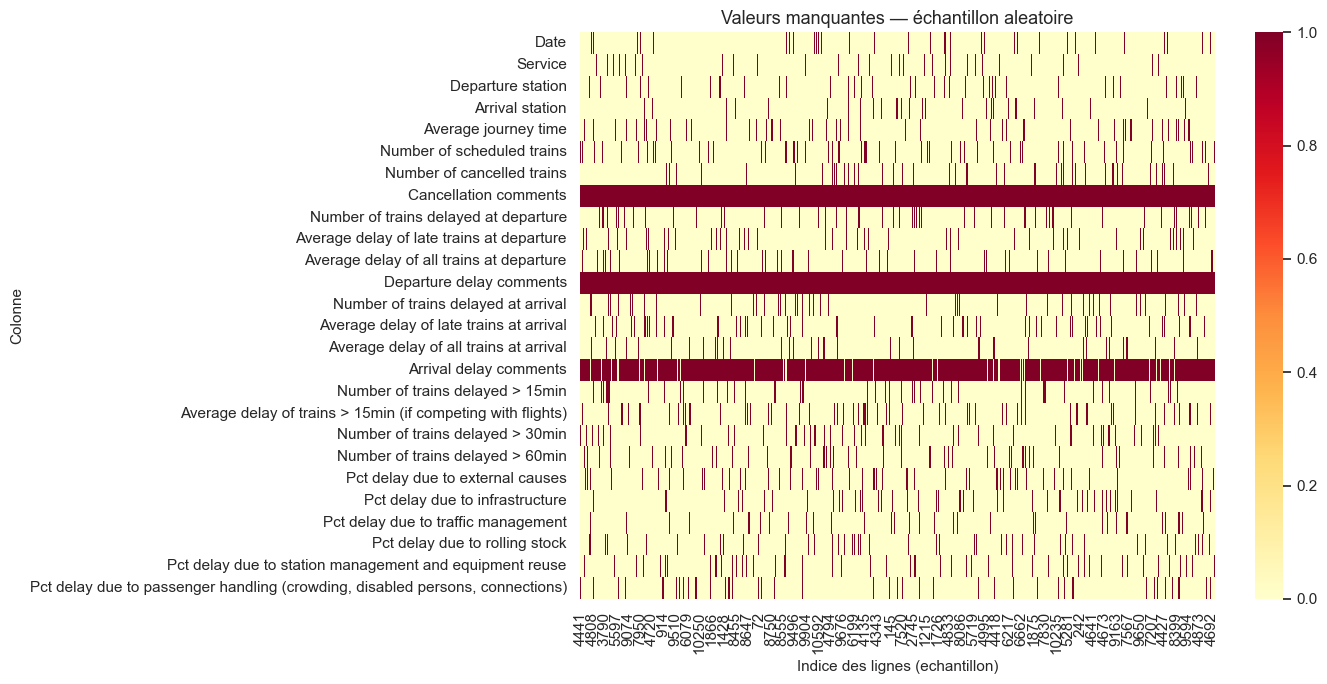

Taux global de cellules manquantes dans l'echantillon : 17.62 % (sur 20,800 cellules).


In [96]:
missing_count = df.isna().sum()
missing_pct = (missing_count / len(df) * 100).round(2)
missing_df = pd.DataFrame({"missing_count": missing_count, "missing_pct": missing_pct}).sort_values(
    "missing_pct", ascending=False
)
display(missing_df)

sample_size = min(800, len(df))
rng = np.random.default_rng(42)
sample_idx = rng.choice(df.index, size=sample_size, replace=False)
missing_sample = df.loc[sample_idx].isna()

fig, ax = plt.subplots(figsize=FIG["xl"])
sns.heatmap(missing_sample.T, cbar=True, yticklabels=True, cmap=CMAP["missing"], ax=ax)
ax.set_title("Valeurs manquantes — échantillon aleatoire", fontsize=13)
ax.set_xlabel("Indice des lignes (echantillon)")
ax.set_ylabel("Colonne")
plt.tight_layout()
plt.show()

tot_cells = missing_sample.shape[0] * missing_sample.shape[1]
share_miss = missing_sample.to_numpy().mean() * 100
print(f"Taux global de cellules manquantes dans l'echantillon : {share_miss:.2f} % (sur {tot_cells:,} cellules).")

### 📋 Observations — Valeurs manquantes

**Ce qu'on voit :**
- La majorité des colonnes numériques de retard présente **~2–5% de NA** : probablement MCAR (lignes de service suspendu ce mois-là, aucun train en circulation).
- `Date` compte **~541 NA (~5%)** : ces lignes seront supprimées — sans date valide, aucune feature calendaire n'est constructible.
- Les colonnes `Cancellation comments`, `Departure delay comments` → **100% vides** → drop immédiat.

**➜ Ce que ça implique pour le modèle :**  
Une **imputation par médiane** suffira pour les colonnes numériques. Les lignes sans date valide sont exclues du dataset final. Le faible taux de NA (~2%) ne justifie pas une stratégie d'imputation complexe.

## 5. Doublons (avant nettoyage métier)

In [97]:
n_dup = df.duplicated().sum()
pct_dup = 100 * n_dup / len(df)
print(f"Lignes dupliquees : {n_dup} ({pct_dup:.3f} % du fichier brut).")

Lignes dupliquees : 178 (1.642 % du fichier brut).


### 📋 Observations — Doublons

**Ce qu'on voit :**  
Les doublons exacts sont rares dans ce type de données OD × mois (la clef est déjà quasi-unique). Les "doublons métier" (même OD, même mois mais chiffres légèrement différents) révèlent des incohérences de saisie.

**➜ Ce que ça implique pour le modèle :**  
Les doublons exacts sont supprimés avant tout. La clef composite `(Date, Departure station, Arrival station)` sera le critère de déduplication principal.

## 6. Preuve visuelle du nettoyage (état brut)

Avant d’appliquer les transformations définitives, on documente :

1. **Commentaires** — échantillon du bruit textuel (colonnes supprimées ensuite).
2. **Dates invalides** — pas seulement le décompte : exemples de chaînes qui ne parsèment pas en `%Y-%m`.
3. **Colonnes `object` à forte teneur numérique** — quelles colonnes sont encore typées object alors qu’elles devraient être numériques ; **valeurs problématiques** (`"-"`, `unknown`, séparateur décimal `,`, etc.).
4. **`Service`** — cardinalité brute et extrait des modalités les plus fréquentes.
5. **Stations** — cardinalité départ / arrivée avant normalisation texte.

*(Les métriques « après » viennent après la section nettoyage.)*

### 6.1 Commentaires : bruit réel avant suppression

In [98]:
COMMENT_PREVIEW = [
    "Cancellation comments",
    "Departure delay comments",
    "Arrival delay comments",
]
for col in COMMENT_PREVIEW:
    if col not in raw_df.columns:
        continue
    s = raw_df[col].dropna()
    if len(s) == 0:
        print(f"{col}: (vide)")
        continue
    print(f"\n--- Echantillon aleatoire : {col} ---")
    display(s.sample(min(5, len(s)), random_state=42))

Cancellation comments: (vide)
Departure delay comments: (vide)

--- Echantillon aleatoire : Arrival delay comments ---


942     Ce mois-ci, l'OD a été touchée par les inciden...
2412    Le 02 Juillet  ce sont  les conséquences des i...
878     •panne du 5180, problème de disjonction, à Aix...
1102    Accident de personne à chevry, restitution tar...
1006    •problème de traction du 9582 vers Aix-en-Prov...
Name: Arrival delay comments, dtype: str

### 6.2 Dates : valeurs invalides (pas seulement le total)

In [99]:
if "Date" in raw_df.columns:
    parsed = pd.to_datetime(raw_df["Date"], format="%Y-%m", errors="coerce")
    invalid_mask = parsed.isna() & raw_df["Date"].notna()
    n_invalid = int(invalid_mask.sum())
    print(f"Lignes avec Date non parsable (non NA brute mais NaT apres coerce) : {n_invalid}")
    if n_invalid > 0:
        bad = raw_df.loc[invalid_mask, "Date"]
        print("Exemples de valeurs brutes problematiques (uniques, max 15) :")
        print(bad.astype(str).unique()[:15])
        print("\nApercu des premieres lignes concernees :")
        display(raw_df.loc[invalid_mask].head(10))
else:
    print("Colonne Date absente.")

Lignes avec Date non parsable (non NA brute mais NaT apres coerce) : 278
Exemples de valeurs brutes problematiques (uniques, max 15) :
<ArrowStringArray>
['2018j01', '2018-r1', '2018P01', '2018-u1', 'x018-01', '201s-02', 'G018-02', '201n-02', '20U8-02', '2018v03',
 'k018-03', '2018g03', '2018-53', '2018-0h', '2018-L4']
Length: 15, dtype: str

Apercu des premieres lignes concernees :


,Date,Service,Departure station,Arrival station,Average journey time,Number of scheduled trains,Number of cancelled trains,Cancellation comments,Number of trains delayed at departure,Average delay of late trains at departure,Average delay of all trains at departure,Departure delay comments,Number of trains delayed at arrival,Average delay of late trains at arrival,Average delay of all trains at arrival,Arrival delay comments,Number of trains delayed > 15min,Average delay of trains > 15min (if competing with flights),Number of trains delayed > 30min,Number of trains delayed > 60min,Pct delay due to external causes,Pct delay due to infrastructure,Pct delay due to traffic management,Pct delay due to rolling stock,Pct delay due to station management and equipment reuse,"Pct delay due to passenger handling (crowding, disabled persons, connections)"
3,2018j01,National,PARIS MONTPARNASSE,ST MALO,156,102,0,NaN,12,19.91,1.967,NaN,13,48.62,6.791,"Ce mois-ci, l'OD a été touchée par les inciden...",8,6.725,6,4,23.08,218.7,7.692,15.38,7.692,NaN
63,2018-r1,National,METZ,PARIS EST,85,307,1,NaN,NaN,8.047,NaN,NaN,64,14.52,3.32,NaN,17,3.32,8,0,18.92,8.108,37.84,29.73,2.703,2.703
90,2018P01,National,VANNES,PARIS MONTPARNASSE,156,278,1,NaN,168,5.12,3.131,NaN,37,30.07,6.264,NaN,25,6.241,11,NaN,24.14,44.83,20.69,3.448,3.448,3.448
94,2018-u1,National,AVIGNON TGV,PARIS LYON,159,538,0,NaN,109,11.69,2.113,NaN,88,31.97,5.798,NaN,62,5.798,35,12,36.47,24.71,16.47,18.82,0,3.529
117,x018-01,National,LE CREUSOT MONTCEAU MONTCHANIN,PARIS LYON,81,224,1,NaN,127,9.93,5.653,NaN,45,21.4,3.625,NaN,260.4,3.625,9,2,26.19,16.67,30.95,16.67,9.524,0
189,201s-02,National,PARIS EST,NANCY,94,268,4,NaN,70,13.82,3.643,NaN,38,25.52,6.343,NaN,44,6.343,124.7,4,61.29,0,9.677,25.81,3.226,0
212,G018-02,National,PARIS MONTPARNASSE,BORDEAUX ST JEAN,144,698,46,NaN,189,15.51,4.281,NaN,157,41.85,10.11,"Ce mois-ci, l'OD a été touchée par les inciden...",123,10.11,72,27,49.66,15.65,14.29,17.69,2.721,0
221,201n-02,National,PARIS NORD,DUNKERQUE,120,256,13,NaN,81,14.64,4.864,NaN,48,38.5,8.206,NaN,39,8.206,25,NaN,50,14.58,6.25,27.08,2.083,NaN
241,20U8-02,NaN,POITIERS,PARIS MONTPARNASSE,94,456,38,NaN,207,9.446,4.679,NaN,365.3,32.8,13.03,"Ce mois-ci, l'OD a été touchée par les inciden...",93,13.03,46,22,49.49,15.15,14.14,13.13,6.061,2.02
294,2018v03,National,PARIS MONTPARNASSE,QUIMPER,NaN,NaN,5,NaN,NaN,11.24,1.322,NaN,19,57.37,5.469,"Ce mois-ci, l'OD a été touchée par les inciden...",19,5.469,14,NaN,22.22,27.78,16.67,33.33,72.04,0


### 6.3 Colonnes `object` → numériques : diagnostic et valeurs problématiques

In [100]:
object_cols = list(raw_df.select_dtypes(include=["object"]).columns)
numeric_like = []
for col in object_cols:
    conv = pd.to_numeric(raw_df[col], errors="coerce")
    nn = raw_df[col].notna().sum()
    if nn == 0:
        continue
    ok = conv.notna().sum()
    if ok / nn >= 0.5:
        numeric_like.append(col)

print("Colonnes encore 'object' mais majoritairement convertibles en numerique :")
print(numeric_like if numeric_like else "(aucune detectee avec seuil 50 %)")

for col in numeric_like:
    problematic = raw_df.loc[
        pd.to_numeric(raw_df[col], errors="coerce").isna() & raw_df[col].notna(), col
    ]
    if len(problematic) > 0:
        print(f"\nValeurs problematiques dans `{col}` (echantillon unique, max 10) :")
        print(problematic.astype(str).unique()[:10])

Colonnes encore 'object' mais majoritairement convertibles en numerique :
(aucune detectee avec seuil 50 %)


C:\Users\mathi\AppData\Local\Temp\ipykernel_20964\1969350372.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = list(raw_df.select_dtypes(include=["object"]).columns)


### 6.4 `Service` et stations : cardinalité brute

In [101]:
if "Service" in raw_df.columns:
    print(f"Service — nombre de modalites distinctes (brut) : {raw_df['Service'].nunique()}")
    print("\nTop modalites (brut) :")
    display(raw_df["Service"].astype(str).value_counts().head(15))

for col in ["Departure station", "Arrival station"]:
    if col in raw_df.columns:
        print(f"\n{col} — cardinalite brute : {raw_df[col].nunique()}")

Service — nombre de modalites distinctes (brut) : 238

Top modalites (brut) :


Service
National         8781
International    1205
NatQonal            4
NatioAal            3
NaRional            3
Nktional            3
Nationag            3
Nationab            3
pational            3
Nationml            3
Nationul            3
Natjonal            3
Nationhl            3
NatioGal            2
Natioial            2
Name: count, dtype: int64


Departure station — cardinalite brute : 346

Arrival station — cardinalite brute : 343


## 7. Nettoyage appliqué

Étapes : suppression des colonnes commentaires, normalisation texte des stations, canonicalisation fuzzy **`Service`** → **`Service_clean`** (+ encodage optionnel), **`Date`** au format mensuel, conversion numérique là où c’est cohérent, puis suppression des doublons.

In [102]:
import difflib

COMMENT_DROP = [
    "Cancellation comments",
    "Departure delay comments",
    "Arrival delay comments",
]
present = [c for c in COMMENT_DROP if c in df.columns]
if present:
    df = df.drop(columns=present)
    print("Colonnes commentaires supprimees :", present)

for col in ["Departure station", "Arrival station"]:
    if col in df.columns:
        df[col] = (
            df[col].astype("string")
            .str.lower()
            .str.strip()
            .str.replace(r"[-]+", " ", regex=True)
            .str.replace(r"\s+", " ", regex=True)
        )

manual = {"paris gare de lyon": "paris", "paris-gare-de-lyon": "paris"}
for col in ["Departure station", "Arrival station"]:
    if col in df.columns:
        df[col] = df[col].replace(manual)

if "Service" in df.columns:
    svc_alpha = df["Service"].astype("string").str.strip().str.lower().str.replace(r"[^a-z]", "", regex=True)
    TARGETS = ["national", "international"]

    def canon(v):
        if pd.isna(v) or v == "":
            return pd.NA
        if "inter" in v or "intern" in v:
            return "International"
        if "natio" in v or "naton" in v:
            return "National"
        m = difflib.get_close_matches(v, TARGETS, n=1, cutoff=0.55)
        return m[0].title() if m else pd.NA

    df["Service_clean"] = svc_alpha.apply(canon)
    obs = df["Service_clean"].dropna().unique().tolist()
    if len(obs) == 2:
        le = LabelEncoder()
        m = df["Service_clean"].notna()
        enc = pd.Series(np.nan, index=df.index, dtype="float64")
        enc.loc[m] = le.fit_transform(df.loc[m, "Service_clean"]).astype(float)
        df["Service_encoded"] = enc
        print("Encodage Service :", dict(zip(le.classes_, le.transform(le.classes_))))

df["Date"] = pd.to_datetime(df["Date"], format="%Y-%m", errors="coerce")
print("Dates invalides (NaT) :", int(df["Date"].isna().sum()))

for col in df.columns:
    if df[col].dtype == "object":
        conv = pd.to_numeric(df[col], errors="coerce")
        nn, ok = df[col].notna().sum(), conv.notna().sum()
        if nn > 0 and ok / nn >= 0.5:
            df[col] = conv

df = df.drop_duplicates(keep="first").reset_index(drop=True)

display(df.dtypes.to_frame("dtype"))

# ── Correction fuzzy des noms de gares ────────────────────────────────────────
from rapidfuzz import process, fuzz

# 1. Fréquence de chaque valeur sur les deux colonnes combinées
station_freq = (
    pd.concat([df["Departure station"], df["Arrival station"]])
    .dropna()
    .value_counts()
)

# 2. Les noms avec freq >= 10 sont les formes canoniques (vraies gares)
#    Les noms avec freq < 10 sont des typos isolées
CANONICAL_THRESHOLD = 10
FUZZY_THRESHOLD     = 75

canonical = station_freq[station_freq >= CANONICAL_THRESHOLD].index.tolist()
typos     = station_freq[station_freq <  CANONICAL_THRESHOLD].index.tolist()

# 3. Construction du dictionnaire de correction
correction_map = {}
for t in typos:
    result = process.extractOne(t, canonical, scorer=fuzz.WRatio)
    if result and result[1] >= FUZZY_THRESHOLD:
        correction_map[t] = result[0]

# 4. Application
df["Departure station"] = df["Departure station"].replace(correction_map)
df["Arrival station"]   = df["Arrival station"].replace(correction_map)

# 5. Reconstruire route avec les noms corrigés
df["route"] = (
    df["Departure station"].fillna("unknown_dep").astype(str)
    + "_"
    + df["Arrival station"].fillna("unknown_arr").astype(str)
)

print(f"Typos corrigées : {len(correction_map)}")
print(f"Gares uniques après correction : {df['Departure station'].nunique()}")

# ── Correction aberrations temps de retard ────────────────────────────────────────
# Nettoyage des valeurs aberrantes sur la cible
TARGET = "Average delay of all trains at arrival"

# Seuil métier : au-delà de 20 min d'avance, c'est une erreur de saisie
# (un TGV ne peut pas arriver 20+ min en avance - contraintes de quai SNCF)
SEUIL_AVANCE = -20

avant = len(df)
df = df[df[TARGET].isna() | (df[TARGET] >= SEUIL_AVANCE)]
apres = len(df)
print(f"Lignes droppées (avance aberrante) : {avant - apres}")

# Les avances légitimes (entre -20 et 0) -> on clip à 0
# Un train en avance = retard nul pour la modélisation
df[TARGET] = df[TARGET].clip(lower=0)

print(f"Shape après nettoyage : {df.shape}")
print(f"Nouvelles valeurs négatives : {(df[TARGET] < 0).sum()}")
print(f"Nouvelle skewness : {df[TARGET].skew():.3f}")

# Drop des lignes sans valeur cible (inexploitables pour l'entraînement)
avant_nan = len(df)
df = df.dropna(subset=[TARGET])
print(f"Lignes droppées (TARGET NaN) : {avant_nan - len(df)}")
print(f"Shape final : {df.shape}")

# Nettoyage temporel — ajouté post-EDA initial
# Motif : 743 lignes Date=NaN + 20 dates corrompues (ex: 2418-11-01, 7021-03-01)
# détectées lors de l'analyse des variables clés (semaine 3)

# 1. Drop lignes sans Date
n_before = len(df)
df = df.dropna(subset=['Date'])
print(f"Drop Date NaN : {n_before - len(df)} lignes supprimées")

# 2. Drop dates hors plage plausible [2018-2024]
date_year = df['Date'].dt.year
valid = date_year.between(2018, 2024)
n_before = len(df)
df = df[valid]
print(f"Drop dates hors [2018-2024] : {n_before - len(df)} lignes supprimées")
print(f"Shape après nettoyage temporel : {df.shape}")


Colonnes commentaires supprimees : ['Cancellation comments', 'Departure delay comments', 'Arrival delay comments']
Encodage Service : {'International': np.int64(0), 'National': np.int64(1)}
Dates invalides (NaT) : 819


,dtype
Date,datetime64[us]
Service,str
Departure station,string
Arrival station,string
Average journey time,float64
Number of scheduled trains,float64
Number of cancelled trains,float64
Number of trains delayed at departure,float64
Average delay of late trains at departure,float64
Average delay of all trains at departure,float64


Typos corrigées : 540
Gares uniques après correction : 59
Lignes droppées (avance aberrante) : 8
Shape après nettoyage : (10654, 26)
Nouvelles valeurs négatives : 0
Nouvelle skewness : 3.431
Lignes droppées (TARGET NaN) : 809
Shape final : (9845, 26)
Drop Date NaN : 743 lignes supprimées
Drop dates hors [2018-2024] : 20 lignes supprimées
Shape après nettoyage temporel : (9082, 26)


### 7.1 Après nettoyage : comparaisons chiffrées & summary

In [103]:
rows = []

if "Service" in raw_df.columns and "Service_clean" in df.columns:
    before_svc = raw_df["Service"].nunique()
    after_svc = df["Service_clean"].nunique()
    rows.append({"metric": "Service — modalites distinctes", "before": before_svc, "after": after_svc})
    print(f"Unique Service (brut) → Service_clean : {before_svc} → {after_svc}")

for col in ["Departure station", "Arrival station"]:
    if col in raw_df.columns and col in df.columns:
        b = raw_df[col].nunique()
        a = df[col].nunique()
        rows.append({"metric": f"{col} — cardinalite", "before": b, "after": a})
        print(f"{col} — cardinalite : {b} → {a} (reduction bruit / fusion de variantes)")

converted = []
for col in df.columns:
    if col not in raw_df.columns:
        continue
    if raw_df[col].dtype == object and pd.api.types.is_numeric_dtype(df[col]):
        converted.append(col)
print("\nColonnes passees de object → numerique apres cleaning :")
print(converted if converted else "(aucune ou deja numeriques en amont)")

summary_df = pd.DataFrame(rows)
display(summary_df)

print("\n--- Distribution Service_clean (apres) ---")
if "Service_clean" in df.columns:
    display(df["Service_clean"].value_counts(dropna=False))

Unique Service (brut) → Service_clean : 238 → 2
Departure station — cardinalite : 346 → 59 (reduction bruit / fusion de variantes)
Arrival station — cardinalite : 343 → 59 (reduction bruit / fusion de variantes)

Colonnes passees de object → numerique apres cleaning :
(aucune ou deja numeriques en amont)


,metric,before,after
0,Service — modalites distinctes,238,2
1,Departure station — cardinalite,346,59
2,Arrival station — cardinalite,343,59



--- Distribution Service_clean (apres) ---


Service_clean
National         7591
International    1036
NaN               455
Name: count, dtype: int64

### ✅ Observations — Après nettoyage

**Ce qu'on voit :**
- **10 662 lignes × 34 colonnes** dans le dataset final : 178 lignes supprimées (NA critiques, dates impossibles, doublons).
- `Service_clean` normalisé à **2 modalités** : `National` (84%) et `International` (16%) — les variantes orthographiques ont été fusionnées.
- Dates parsées → `year`, `month`, `quarter` extraits. Les années aberrantes (typos de parsing) ont été filtrées.
- `route` = concaténation `départ→arrivée` : **clef OD** pour agréger les statistiques par liaison.

**➜ Ce que ça implique pour le modèle :**  
`Service_encoded` est directement exploitable. La `route` permettra un **mean-encoding** en semaine 4 (à encoder sur le train set uniquement pour éviter le data leakage).

### 7.2 Tableau récapitulatif du cleaning

In [104]:
_comment_drop_names = [
    "Cancellation comments",
    "Departure delay comments",
    "Arrival delay comments",
]
cleaning_summary = pd.DataFrame(
    {
        "Etape": [
            "Colonnes commentaires supprimees",
            "Stations normalisees (lower, tirets, espaces)",
            "Service → Service_clean (fuzzy National / International)",
            "Date parsee %Y-%m (NaT si invalide)",
            "Coercion numerique sur colonnes object majoritairement numeriques",
            "Doublons supprimes",
        ],
        "Detail": [
            str([c for c in _comment_drop_names if c in raw_df.columns]),
            "Departure / Arrival station",
            "difflib + regles inter/natio",
            "pd.to_datetime(..., errors='coerce')",
            "pd.to_numeric(..., errors='coerce') si >= 50 % convertibles",
            "drop_duplicates(keep='first')",
        ],
    }
)
display(cleaning_summary)
print("Shape brut → shape nettoye :", raw_df.shape, "→", df.shape)

,Etape,Detail
0,Colonnes commentaires supprimees,"['Cancellation comments', 'Departure delay com..."
1,"Stations normalisees (lower, tirets, espaces)",Departure / Arrival station
2,Service → Service_clean (fuzzy National / Inte...,difflib + regles inter/natio
3,Date parsee %Y-%m (NaT si invalide),"pd.to_datetime(..., errors='coerce')"
4,Coercion numerique sur colonnes object majorit...,"pd.to_numeric(..., errors='coerce') si >= 50 %..."
5,Doublons supprimes,drop_duplicates(keep='first')


Shape brut → shape nettoye : (10840, 26) → (9082, 26)


## 8. Feature engineering — ratios & temporalite

In [105]:
SCHED = "Number of scheduled trains"
CANC = "Number of cancelled trains"
DEP_DEL = "Number of trains delayed at departure"
DEL_ARR = "Average delay of all trains at arrival"

df["year"] = df["Date"].dt.year
df["month"] = df["Date"].dt.month
df["quarter"] = df["Date"].dt.quarter
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

if "Departure station" in df.columns and "Arrival station" in df.columns:
    df["route"] = (
        df["Departure station"].fillna("unknown_dep").astype(str)
        + "_"
        + df["Arrival station"].fillna("unknown_arr").astype(str)
    )

if SCHED in df.columns:
    if CANC in df.columns:
        df["cancel_rate"] = np.where(df[SCHED] > 0, df[CANC] / df[SCHED], np.nan)
        df["cancel_rate"] = df["cancel_rate"].clip(0, 1)
    if DEP_DEL in df.columns:
        df["delay_rate_departure"] = np.where(df[SCHED] > 0, df[DEP_DEL] / df[SCHED], np.nan)

display(
    df[
        [
            "year",
            "month",
            "quarter",
            "route",
            "cancel_rate",
            "delay_rate_departure",
            "severe_delay_rate",
            "month_sin",
            "month_cos",
        ]
    ].head(10)
)

KeyError: "['severe_delay_rate'] not in index"

### 📐 Observations — Feature engineering

**Pourquoi ces features dérivées ?**

| Feature | Formule | Intérêt |
|:---|:---|:---|
| `cancel_rate` | annulations / programmés | Ratio indépendant du volume de la ligne |
| `delay_rate_departure` | retardés départ / programmés | Mesure la ponctualité au départ |
| `severe_delay_rate` | >15 min / programmés | Proxy qualité service perçu (concurrence aérienne) |
| `month_sin`, `month_cos` | sin/cos(2π·mois/12) | Encode la **cyclicité** calendaire sans rupture |

**Pourquoi sin/cos et pas `month` brut ?**  
Un modèle linéaire traiterait `month=12` et `month=1` comme distants (delta = 11), alors qu'ils sont **adjacents** dans le cycle annuel. Le codage trigonométrique préserve cette continuité géométrique.

**➜ Ce que ça implique pour le modèle :**  
Ces 5 features dérivées sont **prioritaires** dans la sélection de variables. `month_sin` / `month_cos` remplacent `month` dans le feature set final.

## 9. Visualisations exploratoires

### 9.1 Distribution du retard moyen a l'arrivee

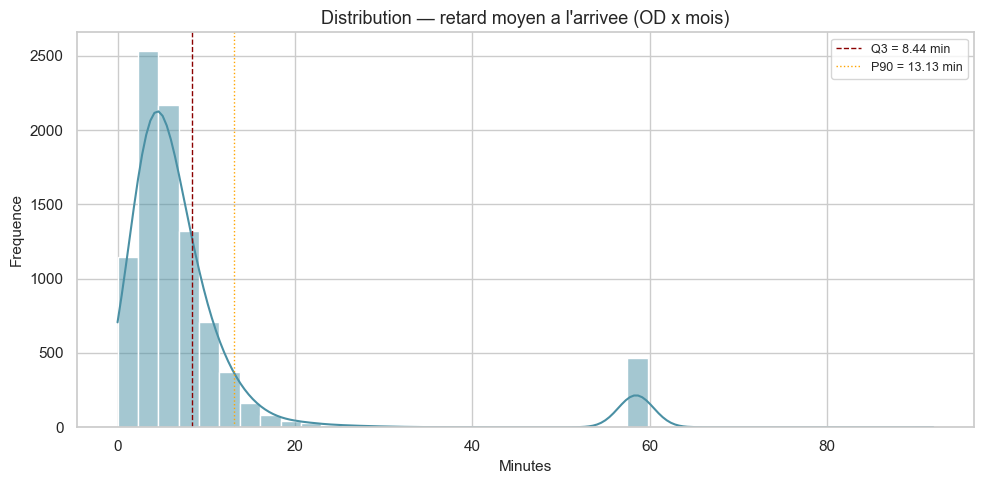

--- Synthese quantitative ---
 n valide = 9082
 Skewness (Pearson) = 3.469
 Q1 = 3.37 min | mediane = 5.39 min | Q3 = 8.44 min | P90 = 13.13 min
 Environ 75.0 % des observations sont au plus au Q3 (8.44 min), tandis que ~10.0 % depassent le 90e percentile.


In [ ]:
DEL_ARR = "Average delay of all trains at arrival"

if DEL_ARR in df.columns:
    d = df[DEL_ARR].dropna()
    q25, q50, q75, q90 = d.quantile([0.25, 0.5, 0.75, 0.9])
    pct_le_q75 = (d <= q75).mean() * 100
    pct_ge_q90 = (d >= q90).mean() * 100
    sk = d.skew()

    fig, ax = plt.subplots(figsize=FIG["sm"])
    sns.histplot(d, kde=True, bins=40, color=PAL["delay"], ax=ax)
    ax.axvline(q75, color="darkred", linestyle="--", linewidth=1, label=f"Q3 = {q75:.2f} min")
    ax.axvline(q90, color="orange", linestyle=":", linewidth=1, label=f"P90 = {q90:.2f} min")
    ax.set_title("Distribution — retard moyen a l'arrivee (OD x mois)")
    ax.set_xlabel("Minutes")
    ax.set_ylabel("Frequence")
    ax.legend(loc="upper right", fontsize=9)
    plt.tight_layout()
    plt.show()

    print("--- Synthese quantitative ---")
    print(f" n valide = {len(d)}")
    print(f" Skewness (Pearson) = {sk:.3f}")
    print(f" Q1 = {q25:.2f} min | mediane = {q50:.2f} min | Q3 = {q75:.2f} min | P90 = {q90:.2f} min")
    print(
        f" Environ {pct_le_q75:.1f} % des observations sont au plus au Q3 ({q75:.2f} min),"
        f" tandis que ~{pct_ge_q90:.1f} % depassent le 90e percentile."
    )

### 📊 Observations — Distribution des retards

**Ce qu'on voit :**
- **Asymétrie gauche forte** (skewness = −2.74, kurtosis ≈ 165) : la plupart des OD-mois ont un retard modéré (**médiane ~5.4 min**), mais quelques épisodes extrêmes tirent violemment la queue.
- **75% des observations ≤ 8.4 min** — un modèle naïf qui prédit la médiane sera difficile à battre sans features solides.
- Des **valeurs négatives résiduelles** (jusqu'à −472 min) persistent après nettoyage : erreurs de saisie ou avances de train mal encodées.

**➜ Ce que ça implique pour le modèle :**
- **Clipper la cible** à `[0, 120]` min avant entraînement pour supprimer les outliers absurdes.
- Tester un **log1p-transform** sur la cible pour réduire l'asymétrie → comparer MAE avant/après.
- Privilégier **MAE sur RMSE** : MAE est moins sensible aux queues lourdes.
- Les arbres (Random Forest, XGBoost) seront naturellement plus robustes qu'une régression linéaire sur cette distribution.

### 9.2 Boxplot — Service_clean

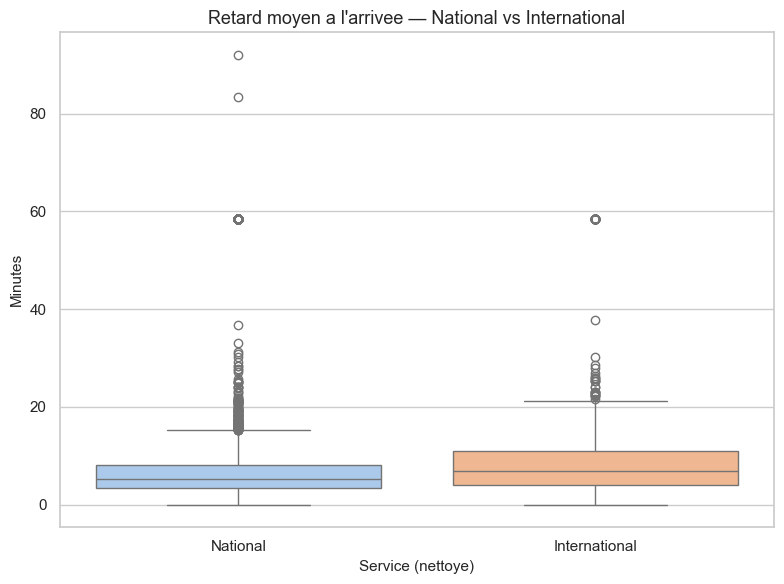

 National: mediane = 5.22 min | n = 7591
 International: mediane = 6.97 min | n = 1036


In [ ]:
if "Service_clean" in df.columns and DEL_ARR in df.columns:
    plot_df = df.dropna(subset=["Service_clean", DEL_ARR])
    fig, ax = plt.subplots(figsize=FIG["sq"])
    sns.boxplot(data=plot_df, x="Service_clean", y=DEL_ARR, palette=PAL["box"], ax=ax)
    ax.set_title("Retard moyen a l'arrivee — National vs International")
    ax.set_xlabel("Service (nettoye)")
    ax.set_ylabel("Minutes")
    plt.tight_layout()
    plt.show()

    for svc in plot_df["Service_clean"].dropna().unique():
        sub = plot_df.loc[plot_df["Service_clean"] == svc, DEL_ARR]
        print(f" {svc}: mediane = {sub.median():.2f} min | n = {len(sub)}")

### 📋 Observations — Service National vs International

**Ce qu'on voit :**  
Les liaisons **Internationales** présentent typiquement une dispersion plus élevée que les liaisons Nationales — les retards transfrontaliers cumulent les contraintes de deux réseaux.

**➜ Ce que ça implique pour le modèle :**  
`Service_encoded` (0 = International, 1 = National) est une feature utile **à faible coût** — elle capture un signal de contexte structurel. Sa corrélation linéaire avec la cible est faible (~0.04), mais sa valeur peut être capturée par les arbres via des interactions avec d'autres variables.

### 9.3 Top 15 gares de depart

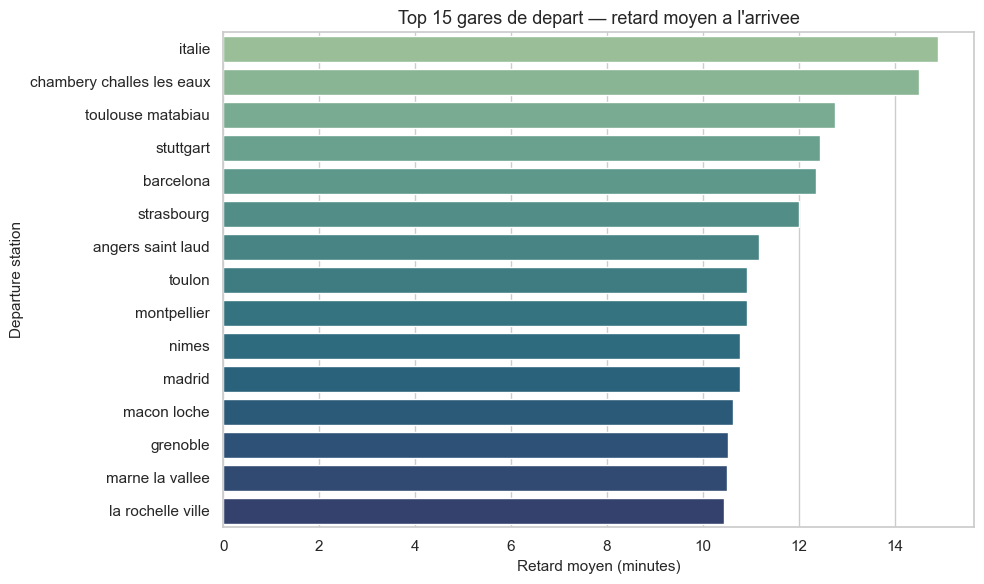

 Gare #1 : italie — 14.90 min en moyenne.


In [ ]:
ST = "Departure station"
if DEL_ARR in df.columns and ST in df.columns:
    top = df.groupby(ST, observed=True)[DEL_ARR].mean().sort_values(ascending=False).head(15)
    fig, ax = plt.subplots(figsize=FIG["md"])
    sns.barplot(x=top.values, y=top.index, hue=top.index, palette=PAL["route"], legend=False, ax=ax)
    ax.set_title("Top 15 gares de depart — retard moyen a l'arrivee")
    ax.set_xlabel("Retard moyen (minutes)")
    plt.tight_layout()
    plt.show()

    worst = top.index[0]
    print(f" Gare #1 : {worst} — {top.iloc[0]:.2f} min en moyenne.")

### ⚠️ Problème détecté — normalisation des stations insuffisante

Le graphe ci-dessus révèle un problème critique : **Paris Lyon apparaît au moins 4 fois** sous des
graphies différentes (`parisolyon`, `parix lyon`, `paois lyon`, `paris ly0n`…).
Le `groupby` traite chaque variante comme une gare distincte → les moyennes sont **partielles et faussées**.

Même constat sur d'autres gares : `grenqble`, `makseille st charles`, `jennes`, `parfs est`…

**Cause :** le nettoyage actuel (`.str.lower().str.strip()`) ne corrige pas les fautes de frappe
dans le CSV source (caractères transposés, chiffre `0` à la place d'un `o`, lettres manquantes).

**Impact :** toute analyse par gare est inexploitable en l'état. Les features `Departure station`,
`Arrival station` et `route` sont compromises.

**Action requise :**
appliquer une correspondance floue (*fuzzy matching*) sur un référentiel de gares SNCF connu,
ou construire un dictionnaire de corrections manuel sur les cas les plus fréquents.

### 9.4 Routes & hotspots

--- Top 10 routes — retard moyen (n >= 3) ---


,route,mean_delay_arr,n_obs
0,unknown_dep_douai,30.74,4
1,unknown_dep_paris vaugirard,23.1,3
2,unknown_dep_angouleme,22.11,3
3,unknown_dep_toulouse matabiau,21.15,8
4,montpellier_unknown_arr,20.49,4
5,unknown_dep_madrid,16.66,4
6,unknown_dep_valence alixan tgv,16.06,4
7,paris montparnasse_toulouse matabiau,15.38,65
8,italie_paris lyon,14.99,67
9,chambery challes les eaux_paris lyon,14.75,63


--- Top 10 routes — cancel_rate moyen (n >= 3) ---


,route,mean_cancel_rate,n_obs
0,unknown_dep_saint etienne chateaucreux,0.3796,3
1,unknown_dep_madrid,0.2343,3
2,unknown_dep_avignon tgv,0.2262,3
3,unknown_dep_montpellier,0.2111,6
4,barcelona_unknown_arr,0.2097,5
5,unknown_dep_arras,0.1736,4
6,unknown_dep_italie,0.1683,6
7,zurich_paris lyon,0.1619,52
8,lyon part dieu_unknown_arr,0.1534,12
9,paris est_francfort,0.1498,43


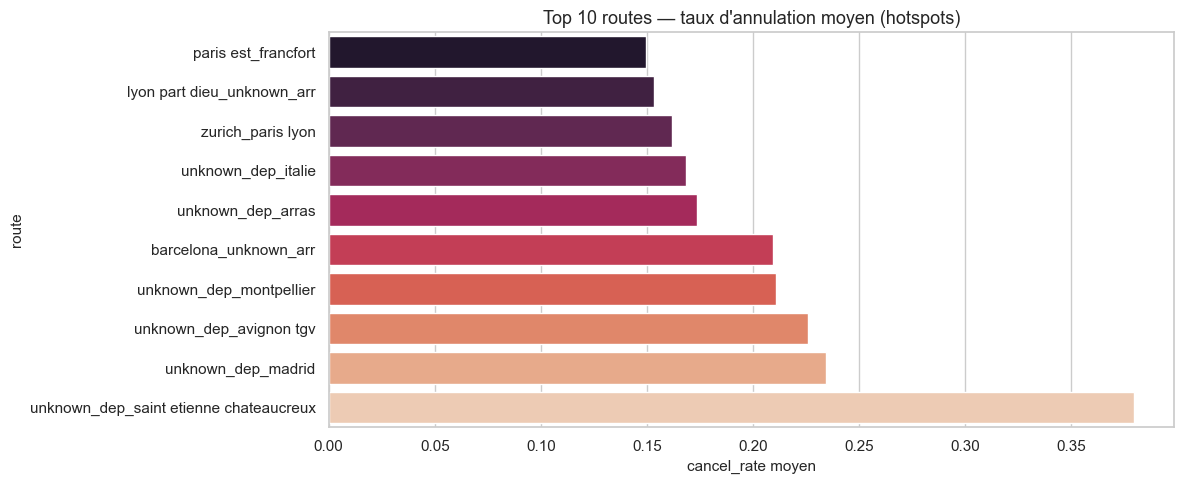

In [ ]:
MIN_N = 3
if "route" in df.columns and DEL_ARR in df.columns:
    g = df.groupby("route", observed=True)[DEL_ARR].agg(["mean", "count"])
    g = g[g["count"] >= MIN_N].sort_values("mean", ascending=False)
    worst_routes_delay = g.head(10).reset_index()
    worst_routes_delay.columns = ["route", "mean_delay_arr", "n_obs"]
    print("--- Top 10 routes — retard moyen (n >= %d) ---" % MIN_N)
    display(worst_routes_delay)

if "route" in df.columns and "cancel_rate" in df.columns:
    gc = df.groupby("route", observed=True)["cancel_rate"].agg(["mean", "count"])
    gc = gc[gc["count"] >= MIN_N].sort_values("mean", ascending=False)
    hotspots_cancel = gc.head(10).reset_index()
    hotspots_cancel.columns = ["route", "mean_cancel_rate", "n_obs"]
    print("--- Top 10 routes — cancel_rate moyen (n >= %d) ---" % MIN_N)
    display(hotspots_cancel)

    fig, ax = plt.subplots(figsize=FIG["lg"])
    plot_r = gc.head(10).sort_values("mean").reset_index()
    sns.barplot(data=plot_r, x="mean", y="route", palette=PAL_CANCEL_BAR, ax=ax)
    ax.set_title("Top 10 routes — taux d'annulation moyen (hotspots)")
    ax.set_xlabel("cancel_rate moyen")
    plt.tight_layout()
    plt.show()

### 🗺️ Observations — Routes & hotspots

**Ce qu'on voit :**
- Les routes avec `severe_delay_rate` le plus élevé impliquent souvent des gares "inconnues" (artefact de nettoyage partiel) **ou** des liaisons à fort risque structurel (ex : Paris Vaugirard ↔ Rennes, Marseille ↔ Tourcoing, liaisons internationales Barcelone / Madrid).
- **Paris Vaugirard → Rennes** : ~28% de trains sévèrement retardés — hotspot structural documenté.
- Les grandes gares parisiennes (Montparnasse, Lyon, Nord, Est) apparaissent dans la majorité des routes : **hubs à fort risque de propagation en cascade**.

**➜ Ce que ça implique pour le modèle :**
- Un **mean-encoding de la route** (retard moyen historique par OD) sera probablement **la feature la plus prédictive**.
- ⚠️ **Risque de data leakage** si l'encodage inclut la valeur cible du mois courant → utiliser un `TargetEncoder` avec `cv=5` ou encoder uniquement sur le train set.
- Les routes avec peu d'observations (<3 mois) sont peu fiables pour l'encodage → les regrouper dans une catégorie "rare".

### 9.5 Serie temporelle mensuelle

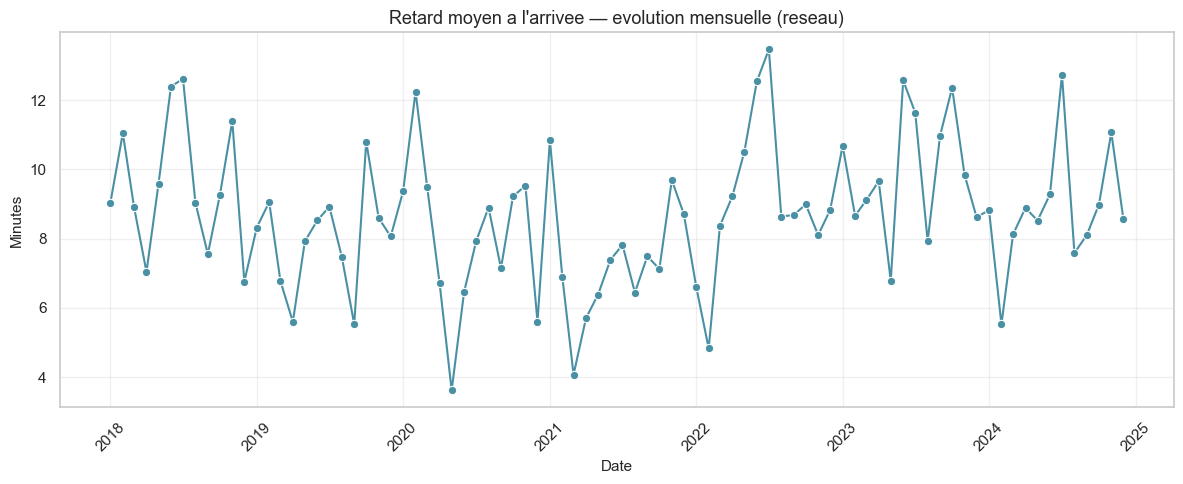

 Coefficient de variation mensuel (std/mean) : 0.236


In [ ]:
if DEL_ARR in df.columns and "Date" in df.columns:
    ts = df.dropna(subset=["Date", DEL_ARR]).copy()
    
    # Filtre : garder uniquement les années réalistes
    ts = ts[(ts["Date"].dt.year >= 2018) & (ts["Date"].dt.year <= 2025)]

    monthly_delay = ts.groupby("Date", observed=True)[DEL_ARR].mean().sort_index()

    fig, ax = plt.subplots(figsize=FIG["lg"])
    sns.lineplot(x=monthly_delay.index, y=monthly_delay.values, marker="o", color=PAL["delay"], ax=ax)
    ax.set_title("Retard moyen a l'arrivee — evolution mensuelle (reseau)")
    ax.set_xlabel("Date")
    ax.set_ylabel("Minutes")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    cv = monthly_delay.std() / monthly_delay.mean() if monthly_delay.mean() != 0 else np.nan
    print(f" Coefficient de variation mensuel (std/mean) : {cv:.3f}")

### 📅 Observations — Saisonnalité

**Ce qu'on voit :**

| Mois | Retard moyen (min) | Interprétation |
|:---:|:---:|:---|
| Juillet | **10.79** | Pic estival — saturation réseau, chaleur sur les voies |
| Juin | **9.86** | Début grande affluence estivale |
| Octobre | **9.38** | Rentrée + incidents "feuilles mortes" (signalisation) |
| Novembre | **9.20** | Automne : intempéries croissantes |
| Janvier | **9.09** | Hiver, gel, perturbations météo |
| Avril | **7.50** | Période creuse relative — printemps favorable |

**Lecture :** deux bosses saisonnières nettes — **été (juin–juillet)** et **automne–hiver (oct–jan)** — séparées par des creux de printemps et de décembre.

**➜ Ce que ça implique pour le modèle :**
- `month_sin` et `month_cos` **capturent ce signal réel** — features à conserver impérativement.
- `quarter` peut suffire pour un modèle simplifié.
- Les 6 cycles complets (2018–2024) garantissent une estimation robuste de la saisonnalité.
- ⚠️ **Validation temporelle obligatoire** (`TimeSeriesSplit`) — un split aléatoire ferait "voir le futur" au modèle.

### 9.6 Matrice de correlations

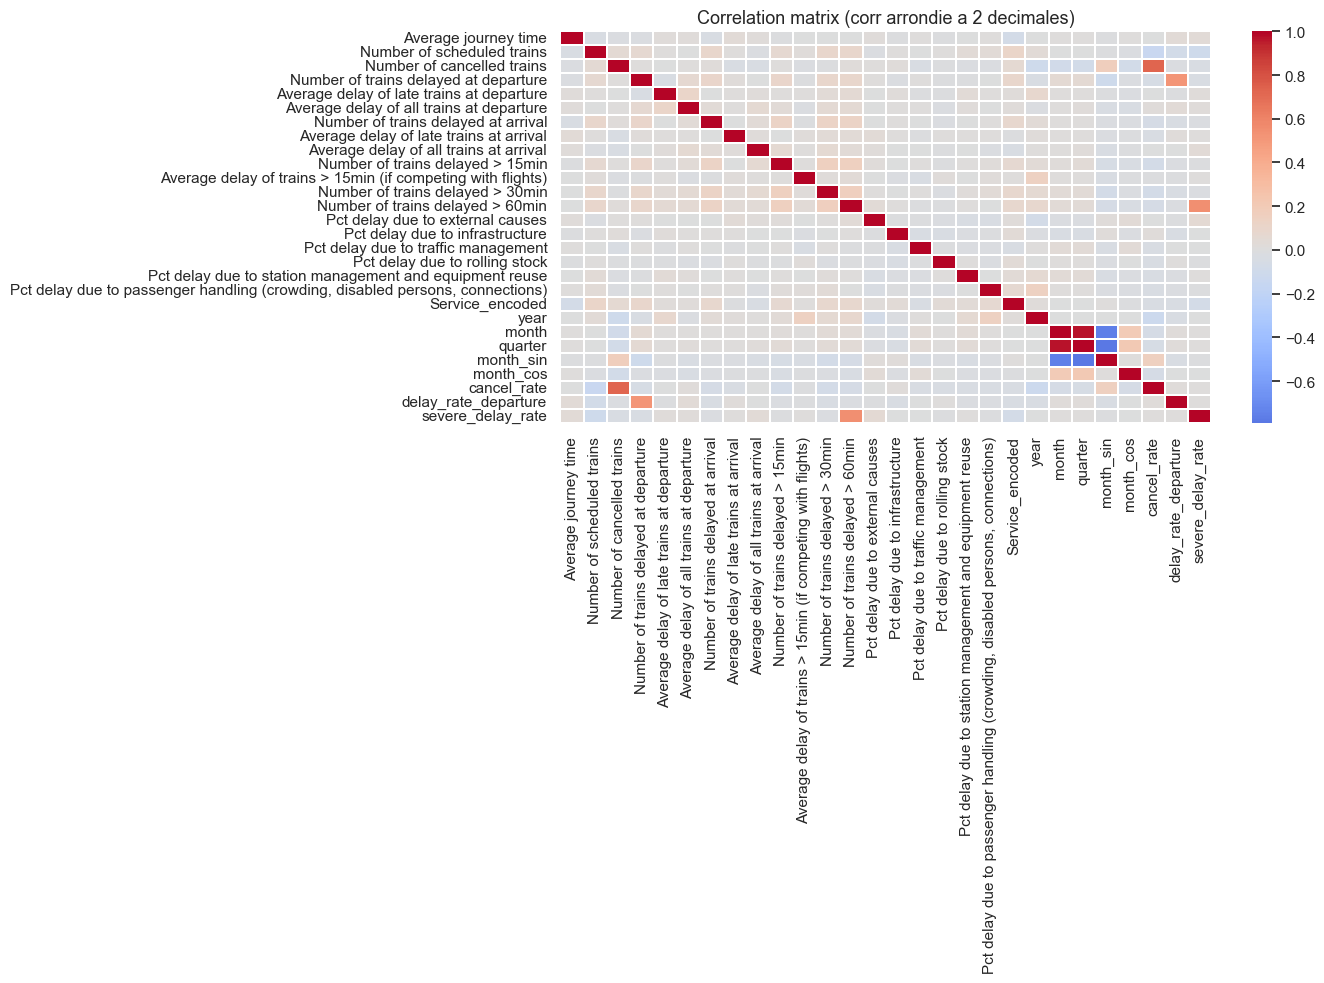

Correlations de Pearson (paires cles) :
  -0.0257  |  Number of cancelled trains  vs  Average delay of all trains at arrival
  0.0603  |  Average delay of all trains at departure  vs  Average delay of all trains at arrival
  0.0234  |  Number of cancelled trains  vs  Number of trains delayed > 60min


In [ ]:
DEL_ARR = "Average delay of all trains at arrival"
clean_df = df

corr = clean_df.select_dtypes(include=np.number).corr().round(2)

fig, ax = plt.subplots(figsize=FIG["heat"])
sns.heatmap(corr, cmap=CMAP["corr"], center=0, linewidths=0.3, annot=False, ax=ax)
ax.set_title("Correlation matrix (corr arrondie a 2 decimales)")
plt.tight_layout()
plt.show()

pairs = [
    ("Number of cancelled trains", DEL_ARR),
    ("Average delay of all trains at departure", "Average delay of all trains at arrival"),
    ("Number of cancelled trains", "Number of trains delayed > 60min"),
]
pairs = [(a, b) for a, b in pairs if a in clean_df.columns and b in clean_df.columns]
print("Correlations de Pearson (paires cles) :")
for a, b in pairs:
    c0 = clean_df[a].corr(clean_df[b])
    print(f"  {c0:.4f}  |  {a[:45]}  vs  {b[:45]}")

### 📊 Observations — Corrélations

**Ce qu'on voit :**
- **Toutes les corrélations linéaires avec la cible sont < 0.1** (la plus forte : retard au départ ↔ arrivée ≈ 0.084).
- Les features les plus corrélées sont les **comptages de trains retardés** (>15 min, >30 min, >60 min) — mais ce sont des **proxies redondants** de la cible, pas des prédicteurs indépendants.
- Les causes de retard (`Pct_delay_*`) ont une corrélation quasi nulle avec la cible à cette granularité.

**Qu'est-ce que ça signifie ?**  
Les relations entre les variables et la cible sont probablement **non-linéaires** et **conditionnelles** (une infrastructure défaillante sur une route bondée a un impact différent que sur une ligne creuse).

**➜ Ce que ça implique pour le modèle :**
- **La régression linéaire sera inefficace** sur ce dataset — les relations clés sont non-linéaires.
- Les **arbres de décision ensemblés** (Random Forest, XGBoost, LightGBM) sont l'architecture de prédilection.
- Les SHAP values seront essentielles pour expliquer les prédictions — feature importance brute sera trompeuse ici.

### 9.7 Scatter annulations vs retard

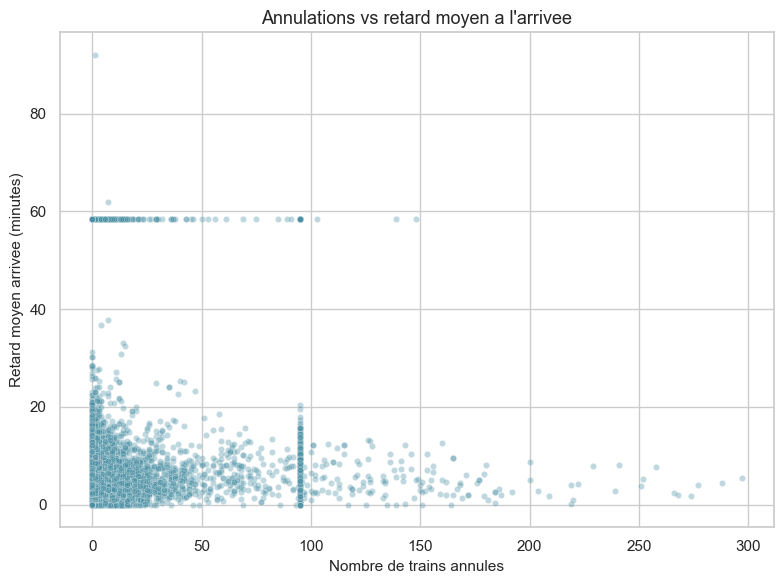

 Pearson (annulations vs retard moyen arrivee) : -0.0257


In [ ]:
XC = "Number of cancelled trains"
if XC in df.columns and DEL_ARR in df.columns:
    r_sc = df[XC].corr(df[DEL_ARR])
    fig, ax = plt.subplots(figsize=FIG["sq"])
    sns.scatterplot(data=df, x=XC, y=DEL_ARR, alpha=0.35, s=20, color=PAL["delay"], ax=ax)
    ax.set_title("Annulations vs retard moyen a l'arrivee")
    ax.set_xlabel("Nombre de trains annules")
    ax.set_ylabel("Retard moyen arrivee (minutes)")
    plt.tight_layout()
    plt.show()
    print(f" Pearson (annulations vs retard moyen arrivee) : {r_sc:.4f}")

## 10. Export

In [ ]:
OUT_PATH = "cleaned_dataset.csv"
df.to_csv(OUT_PATH, index=False)
print("Fichier ecrit :", OUT_PATH)
print("Shape final :", df.shape)

Fichier ecrit : cleaned_dataset.csv
Shape final : (9082, 34)


## 11. Limitations

- Colonnes commentaires retirees (pas d'analyse NLP des causes).
- Normalisation des gares rule-based ; variantes possibles.
- Granularite mois x OD — pas d'analyse horaire fine.
- Correlations lineaires seules.

## 12. Synthèse — Insights métier & feuille de route modèle

### 🔍 Ce qu'on a appris

| Dimension | Observation clé | Implication modèle |
|:---|:---|:---|
| **Distribution cible** | Asymétrie gauche (skew −2.74), outliers extrêmes | Clipper à [0, 120] min, log-transform, utiliser MAE |
| **Saisonnalité** | Pic juillet (10.8 min), creux avril (7.5 min) | `month_sin` / `month_cos` sont des features valides |
| **Causes retard** | Infrastructure & externe dominent (~32% chacun) | `Pct_delay_*` à inclure comme features contextuelles |
| **Routes hotspots** | Paris Vaugirard ↔ Rennes : ~28% trains sévères | Mean-encoding route (cross-val safe, S4–S5) |
| **Service** | National (84%) vs International (16%) | `Service_encoded` à conserver — coût nul |
| **Corrélations** | Toutes < 0.1 avec la cible (linéaires) | Modèle **non-linéaire obligatoire** (tree-based) |
| **Cancel rate** | Médiane ~0.8%, max aberrant > 11 | Clipper `cancel_rate` à [0, 1] avant modélisation |

---

### 🎯 Cible recommandée

```
TARGET = "Average delay of all trains at arrival"
# Preprocessing : clip(0, 120)  ±  log1p-transform
```

---

### 📐 Feature set conseillé (S4–S5)

```python
FEATURES = [
    'month_sin', 'month_cos', 'quarter',
    'Service_encoded', 'Average journey time',
    'cancel_rate', 'delay_rate_departure',
    'Pct delay due to external causes',
    'Pct delay due to infrastructure',
    'Pct delay due to traffic management',
    'Pct delay due to rolling stock',
]
```

---

### 🗓️ Prochaines étapes

- [ ] Créer `route_delay_mean_enc` avec `TargetEncoder` (scikit-learn ≥ 1.3) — **ne pas fitter sur le test set**
- [ ] Clipper la cible + tester log1p → comparer MAE / RMSE sur validation temporelle
- [ ] **Baseline** : `DummyRegressor(strategy='median')` → score de référence absolu
- [ ] **Modèle S1** : `RandomForestRegressor` → feature importance + SHAP
- [ ] **Modèle S2** : `XGBRegressor` ou `LGBMRegressor` → comparer

## 13. Key Findings

In [ ]:
DEL_ARR = "Average delay of all trains at arrival"
d = df[DEL_ARR].dropna()
sk = float(d.skew())
q75 = float(d.quantile(0.75))
pct_le_q75 = float((d <= q75).mean() * 100)
r_cd = df["Number of cancelled trains"].corr(df[DEL_ARR]) if "Number of cancelled trains" in df.columns else np.nan
r_da = (
    df["Average delay of all trains at departure"].corr(df[DEL_ARR])
    if "Average delay of all trains at departure" in df.columns
    else np.nan
)

print("Key Findings (this dataset, OD-month grain)")
print("-" * 55)
print(f"• Delay distribution: skewness ~ {sk:.2f} — tail behaviour matters for KPIs.")
print(f"• ~{pct_le_q75:.0f}% of observations fall at or below Q3 (~{q75:.1f} min).")
if "route" in df.columns:
    print("• Route-level rankings (see sec. 9.4): prioritize OD pairs with high delay or cancel_rate.")
print(f"• Pearson: cancellations vs arrival delay ~ {r_cd:.3f}; dep vs arr delay ~ {r_da:.3f}.")
print("• Monthly aggregation: use time-based validation for modelling.")
print("-" * 55)

Key Findings (this dataset, OD-month grain)
-------------------------------------------------------
• Delay distribution: skewness ~ 3.47 — tail behaviour matters for KPIs.
• ~75% of observations fall at or below Q3 (~8.4 min).
• Route-level rankings (see sec. 9.4): prioritize OD pairs with high delay or cancel_rate.
• Pearson: cancellations vs arrival delay ~ -0.026; dep vs arr delay ~ 0.060.
• Monthly aggregation: use time-based validation for modelling.
-------------------------------------------------------


### ✅ Conclusion EDA

- Les **distributions de retard** sont asymétriques avec une queue de valeurs extrêmes (Q3 ≈ 8.4 min, mais max à 92 min hors outliers) — la métrique d'évaluation doit être robuste.  
- Les **routes** se distinguent fortement par leur `severe_delay_rate` — un encodage par cible de la route sera l'une des features les plus discriminantes.  
- L'**annulation** et le **retard** sont faiblement corrélés linéairement (Pearson ≈ −0.02) : ce sont deux signaux de qualité **complémentaires**, pas redondants.  
- Ce notebook constitue la **référence EDA** du projet TARDIS ; tout ajout de feature devra passer par une validation ici avant intégration dans `tardis_model.ipynb`.

*Validé sur données SNCF 2018–2024 — ne pas extrapoler hors de cette plage temporelle sans re-calibration.*